In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Potencial aplicado

In [2]:
# Importar dados
data = np.loadtxt("Log_dt20_2.txt").T

t = data[0]
u1 = data[1]
u2 = data[2]
w1 = data[3]
w2 = data[4]

num = len(t)
print(num) # tem 400 pontos

tau_c = 0.2

400


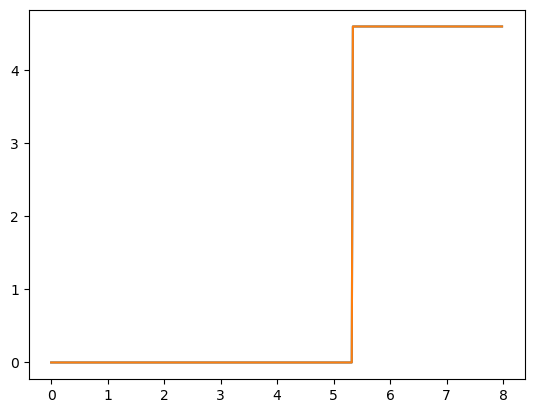

In [3]:
plt.plot(t, u1)
plt.plot(t, u2)
plt.show()

# Resposta sem PID

RODA 1
 - A = 21.71 rad/s
 - τ = 120 ms
 - k_c = 0.028
 - k_i = 0.230


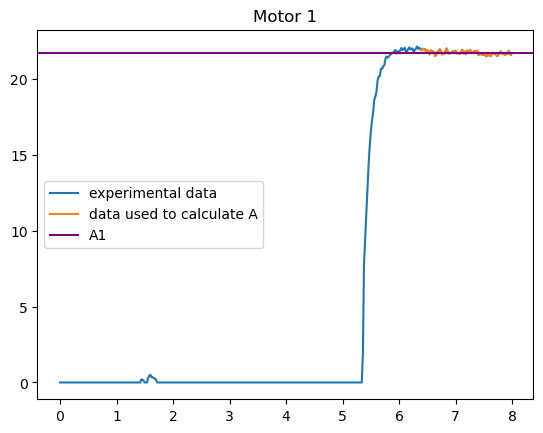

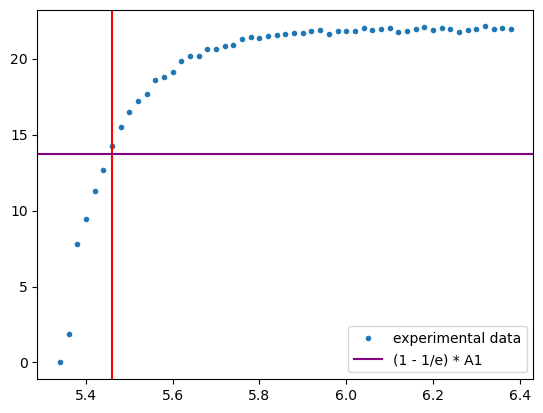

In [4]:
A1 = np.mean(w1[320:])
print(f"RODA 1\n - A = {A1:.2f} rad/s")
A_tau1 = (1 - 1/np.e)*A1 # valor de a
tau1_idx = np.argmin(np.abs(w1 - A_tau1))
tau1 = t[tau1_idx] - t[267]
print(f" - τ = {tau1*1000:.0f} ms")

kc1 = tau1/(tau_c * A1)
print(f" - k_c = {kc1:.3f}")
ki1 = kc1/tau1
print(f" - k_i = {ki1:.3f}")

plt.plot(t, w1, label = 'experimental data')
plt.plot(t[320:], w1[320:], label = "data used to calculate A")
plt.axhline(A1, label = 'A1', color = 'purple')
plt.title("Motor 1")
plt.legend()
plt.show()


plt.plot(t[267:320], w1[267:320], '.', label = "experimental data")
plt.axvline(tau1 + t[267], color = 'red')
plt.axhline(A_tau1, label = '(1 - 1/e) * A1', color = 'purple')
plt.legend()
plt.show()

RODA 2
 - A = 22.82 rad/s
 - τ = 120 ms
 - k_c = 0.026
 - k_i = 0.219


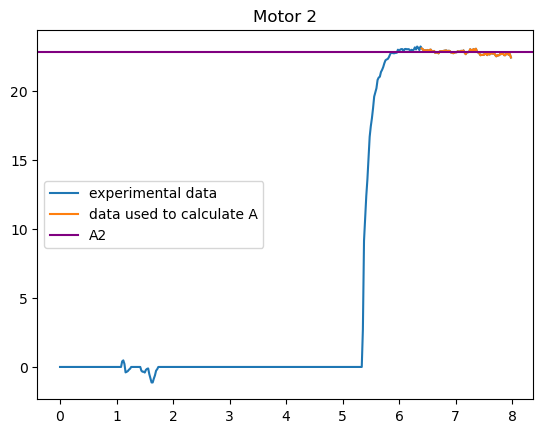

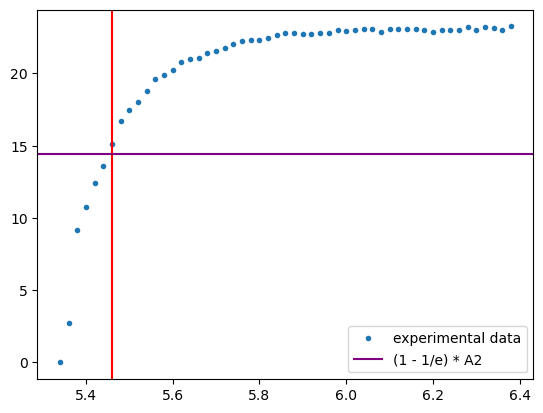

In [5]:
A2 = np.mean(w2[320:])
print(f"RODA 2\n - A = {A2:.2f} rad/s")
A_tau2 = (1 - 1/np.e)*A2 # valor de a
tau2_idx = np.argmin(np.abs(w2 - A_tau2))
tau2 = t[tau2_idx] - t[267]
print(f" - τ = {tau2*1000:.0f} ms")

kc2 = tau2/(tau_c * A2)
print(f" - k_c = {kc2:.3f}")
ki2 = kc2/tau2
print(f" - k_i = {ki2:.3f}")

plt.plot(t, w2, label = 'experimental data')
plt.plot(t[320:], w2[320:], label = "data used to calculate A")
plt.axhline(A2, label = 'A2', color = 'purple')
plt.title("Motor 2")
plt.legend()
plt.show()


plt.plot(t[267:320], w2[267:320], '.', label = "experimental data")
plt.axvline(tau2 + t[267], color = 'red')
plt.axhline(A_tau2, label = '(1 - 1/e) * A2', color = 'purple')
plt.legend()
plt.show()

In [6]:
kc = (kc1 + kc2)/2
ki = (ki1 + ki2)/2
print(f" - k_c = {kc:.3f}")
print(f" - k_i = {ki:.3f}")

 - k_c = 0.027
 - k_i = 0.225


# Resposta com PID

In [7]:
# Importar dados
data_new = np.loadtxt("Log_pid_dt20_2.txt").T

t_new = data_new[0] # neste já nao me esqueci lol
u1_new = data_new[1]
u2_new = data_new[2]
w1_new = data_new[3]
w2_new = data_new[4]

num_new = len(t_new)
print(num_new) # tem 400 pontos

400


RODA 1 com PID
 - A = 21.33 rad/s
 - τ = 140 ms


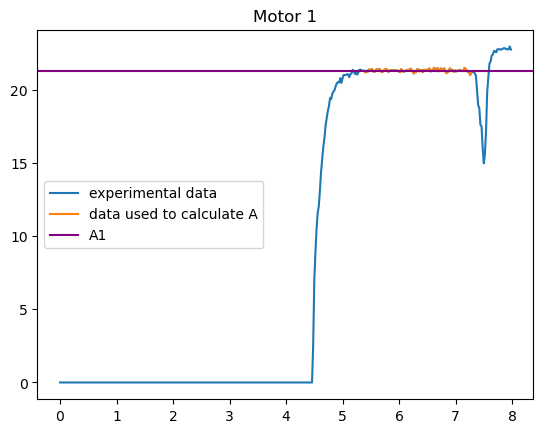

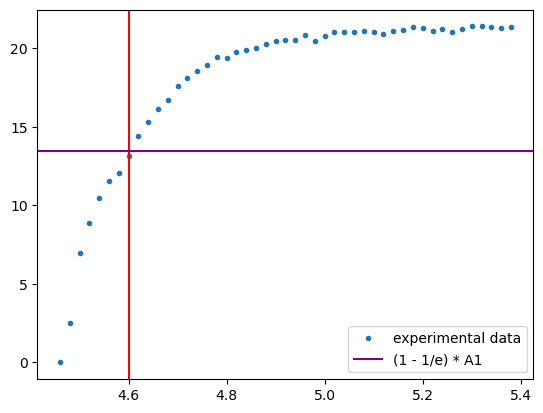

In [8]:
A1_new = np.mean(w1_new[270:-35])
print(f"RODA 1 com PID\n - A = {A1_new:.2f} rad/s")
A_tau1_new = (1 - 1/np.e)*A1_new # valor de a
tau1_idx_new = np.argmin(np.abs(w1_new - A_tau1_new))
tau1_new = t_new[tau1_idx_new] - t_new[223]
print(f" - τ = {tau1_new*1000:.0f} ms")

plt.plot(t_new, w1_new, label = 'experimental data')
plt.plot(t_new[270:-35], w1_new[270:-35], label = "data used to calculate A")
plt.axhline(A1_new, label = 'A1', color = 'purple')
plt.title("Motor 1")
plt.legend()
plt.show()


plt.plot(t_new[223:270], w1_new[223:270], '.', label = "experimental data")
plt.axvline(tau1_new + t_new[223], color = 'red')
plt.axhline(A_tau1_new, label = '(1 - 1/e) * A1', color = 'purple')
plt.legend()
plt.show()

RODA 2
 - A = 22.54 rad/s
 - τ = 100 ms


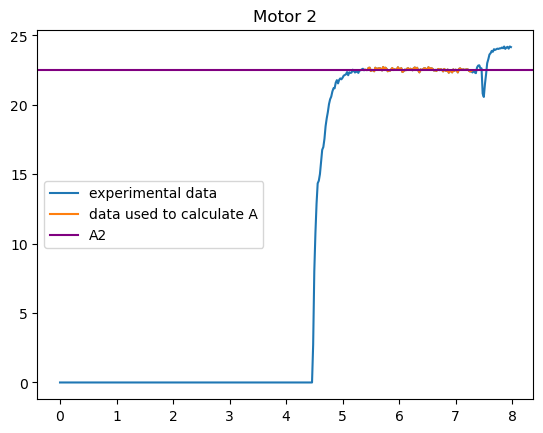

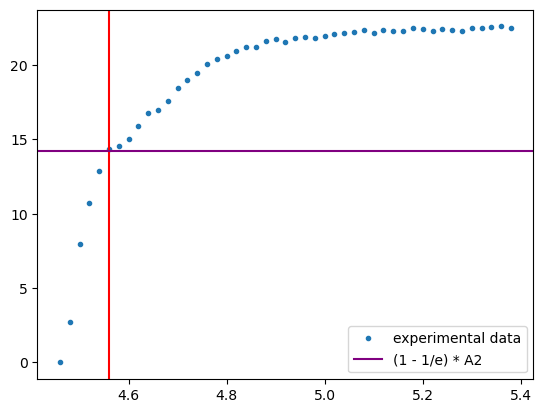

In [9]:
A2_new = np.mean(w2_new[270:-35])
print(f"RODA 2\n - A = {A2_new:.2f} rad/s")
A_tau2_new = (1 - 1/np.e)*A2_new # valor de a
tau2_idx_new = np.argmin(np.abs(w2_new - A_tau2_new))
tau2_new = t_new[tau2_idx_new] - t_new[223]
print(f" - τ = {tau2_new*1000:.0f} ms")

plt.plot(t_new, w2_new, label = 'experimental data')
plt.plot(t_new[270:-35], w2_new[270:-35], label = "data used to calculate A")
plt.axhline(A2_new, label = 'A2', color = 'purple')
plt.title("Motor 2")
plt.legend()
plt.show()


plt.plot(t_new[223:270], w2_new[223:270], '.', label = "experimental data")
plt.axvline(tau2_new + t_new[223], color = 'red')
plt.axhline(A_tau2_new, label = '(1 - 1/e) * A2', color = 'purple')
plt.legend()
plt.show()